<a href="https://colab.research.google.com/github/AdnanOmerbasic/adult-income-ml/blob/main/Adult_income_datas%C3%A6t.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install and imports**

In [69]:
!pip3 install -U ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from ucimlrepo import fetch_ucirepo

# **Get the data**

In [70]:
adult = fetch_ucirepo(id=2)

y = adult.data.targets.copy()
X = adult.data.features.copy()

In [74]:
display(X.head())
display(X.shape)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


(48842, 14)

In [75]:
y.head()

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


In [76]:
X.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


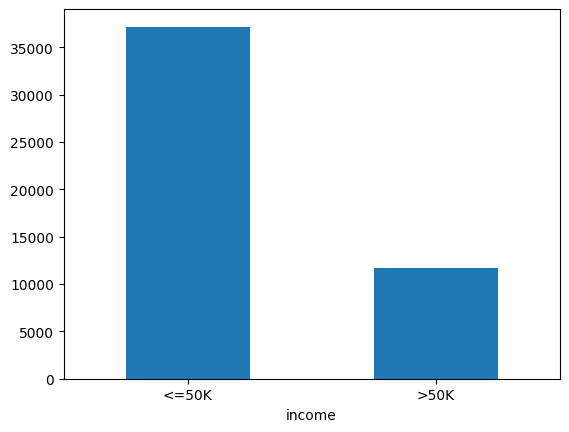

In [77]:
y = adult.data.targets.iloc[:, 0].str.strip().str.rstrip('.')
y.value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.show()

# **Data preparation**

## **Data cleaning**

In [78]:
y = y.map({'<=50K':0, '>50K':1})

X = X.drop(columns=['fnlwgt', 'education'])

In [79]:
display(X.head())
display(y.head())

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


,income
0,0
1,0
2,0
3,0
4,0


## **Pipelines transform**

In [80]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

adult_num = X.select_dtypes(include=[np.number]).columns.tolist()
adult_cat = X.select_dtypes(include='object').columns.tolist()

num_pipeline = make_pipeline(SimpleImputer(strategy='median'))
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(sparse_output=False, handle_unknown='ignore'))

preprocessing_pipeline = ColumnTransformer([('num', num_pipeline, adult_num), ('cat', cat_pipeline, adult_cat)])

# **Split the dataset**

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **Train and finetune with Random forest**

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

random_forest_pipeline = Pipeline([('preprocessing', preprocessing_pipeline),
                                   ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1))])

random_forest_grid_params = {
    'random_forest__n_estimators': [100, 200, 300],
    'random_forest__max_depth': [10, 20, None],
}

grid_search = GridSearchCV(random_forest_pipeline, random_forest_grid_params, cv=5, scoring='f1', n_jobs=-1, error_score='raise')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['age',
                                                                          'education-num',
                                                                          'capital-gain',
                                                                          'capital-loss',
                                                                          'hours-per-week']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot...der',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['workclass',
                                                                          'marital-status',
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex',
                                                                          'native-country'])])),
                                       ('random_forest',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'random_forest__max_depth': [10, 20, None],
                         'random_forest__n_estimators': [100, 200, 300]},
             scoring='f1')

In [83]:
print(f'Best params: {grid_search.best_params_}')
print(f'Best score under CV F1:     {grid_search.best_score_:.2f}')

Best params: {'random_forest__max_depth': 20, 'random_forest__n_estimators': 100}
Best score under CV F1:     0.67


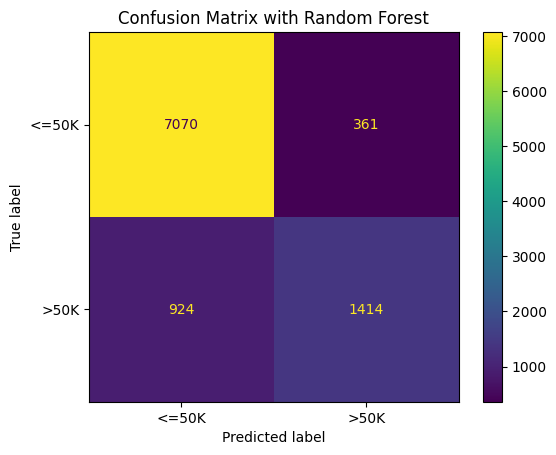

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
random_forest_pred = grid_search.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, random_forest_pred,
    display_labels=["<=50K", ">50K"]
)
plt.title("Confusion Matrix with Random Forest")
plt.show()

# **Random forest evaluation**

In [85]:
print(f'Accuracy: {accuracy_score(y_test, random_forest_pred):.2f}')
print(f'Precision: {precision_score(y_test, random_forest_pred):.2f}')
print(f'Recall: {recall_score(y_test, random_forest_pred):.2f}')
print(f'F1: {f1_score(y_test, random_forest_pred):.2f}')

Accuracy: 0.87
Precision: 0.80
Recall: 0.60
F1: 0.69


In [86]:
print(classification_report(y_test, random_forest_pred, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      7431
        >50K       0.80      0.60      0.69      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769



# **Train and fine tune with Histogram-based Gradient boosting**

In [87]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gb_pipeline = Pipeline([('preprocessing', preprocessing_pipeline),
                             ('hist_gradient_boosting', HistGradientBoostingClassifier(random_state=42))])

hist_gb_params = {
    'hist_gradient_boosting__learning_rate': [0.05, 0.1, 0.2],
    'hist_gradient_boosting__max_iter': [100, 200, 300],
    'hist_gradient_boosting__max_depth': [2, 3, 5, None]
}

hist_gb_search = GridSearchCV(hist_gb_pipeline, hist_gb_params, cv=5, scoring='f1', n_jobs=-1)
hist_gb_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['age',
                                                                          'education-num',
                                                                          'capital-gain',
                                                                          'capital-loss',
                                                                          'hours-per-week']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncod...
                                                                         ['workclass',
                                                                          'marital-status',
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex',
                                                                          'native-country'])])),
                                       ('hist_gradient_boosting',
                                        HistGradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'hist_gradient_boosting__learning_rate': [0.05, 0.1,
                                                                   0.2],
                         'hist_gradient_boosting__max_depth': [2, 3, 5, None],
                         'hist_gradient_boosting__max_iter': [100, 200, 300]},
             scoring='f1')

In [88]:
print(f'Best params: {hist_gb_search.best_params_}')
print(f'Best score under CV F1:     {hist_gb_search.best_score_:.2}')

Best params: {'hist_gradient_boosting__learning_rate': 0.1, 'hist_gradient_boosting__max_depth': None, 'hist_gradient_boosting__max_iter': 100}
Best score under CV F1:     0.71


## **Histogram-based Gradient boosting evaluation**

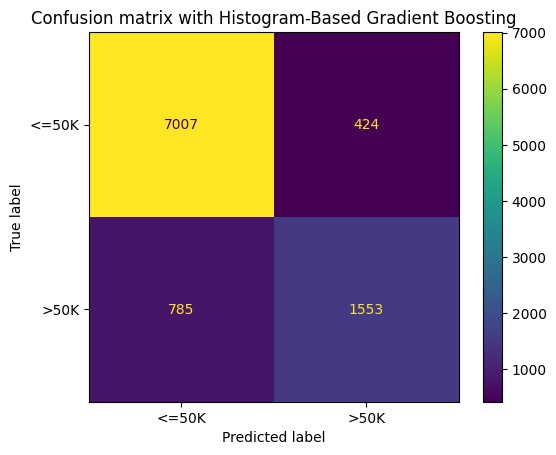

In [89]:
hist_gb_pred = hist_gb_search.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, hist_gb_pred,
    display_labels=['<=50K', '>50K']
)
plt.title('Confusion matrix with Histogram-Based Gradient Boosting')
plt.show()

In [90]:
print(f'Accuracy: {accuracy_score(y_test, hist_gb_pred):.2f}')
print(f'Precision: {precision_score(y_test, hist_gb_pred):.2f}')
print(f'Recall: {recall_score(y_test, hist_gb_pred):.2f}')
print(f'F1: {f1_score(y_test, hist_gb_pred):.2f}')

Accuracy: 0.88
Precision: 0.79
Recall: 0.66
F1: 0.72


In [91]:
print(classification_report(y_test, hist_gb_pred, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      7431
        >50K       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



# **Histogram-based Gradient boosting and Random forest comparison**

In [92]:
comparison_results = pd.DataFrame({
    'Models': ['Random Forest', 'Histogram-Based Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, random_forest_pred),
        accuracy_score(y_test, hist_gb_pred)
    ],
    'Precision': [
        precision_score(y_test, random_forest_pred),
        precision_score(y_test, hist_gb_pred)
    ],
    'Recall': [
        recall_score(y_test, random_forest_pred),
        recall_score(y_test, hist_gb_pred),
    ],
    'F1': [
        f1_score(y_test, random_forest_pred),
        f1_score(y_test, hist_gb_pred)
    ],
})

print(comparison_results.round(2).to_string(index=False))

                           Models  Accuracy  Precision  Recall   F1
                    Random Forest      0.87       0.80    0.60 0.69
Histogram-Based Gradient Boosting      0.88       0.79    0.66 0.72
